In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


In [5]:
# Query the confusion matrix with threshold (18)
query_cm = """
WITH evaluation AS (
    SELECT 
        is_fraud,
        (risk_score >= 18) AS flagged
    FROM fraud_dw.v_scored_transactions
)
SELECT 
    COUNT(*) FILTER (WHERE flagged AND is_fraud)         AS true_positives,
    COUNT(*) FILTER (WHERE flagged AND NOT is_fraud)     AS false_positives,
    COUNT(*) FILTER (WHERE NOT flagged AND is_fraud)     AS false_negatives,
    COUNT(*) FILTER (WHERE NOT flagged AND NOT is_fraud) AS true_negatives
FROM evaluation;
"""

df_cm = pd.read_sql(query_cm, engine)
row = df_cm.iloc[0]

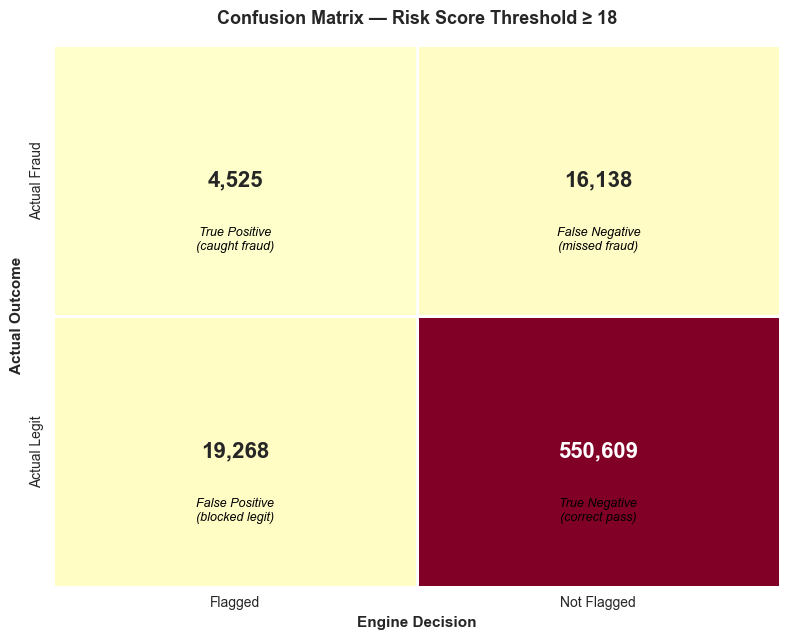

Precision: 19.02%  |  Recall: 21.90%


In [14]:

# Arrange into 2x2 matrix
# Rows = Actual (Fraud / Legit), Columns = Predicted (Flagged / Not Flagged)
cm = np.array([
    [row['true_positives'],  row['false_negatives']],   # Actual Fraud
    [row['false_positives'], row['true_negatives']]      # Actual Legit
])

fig, ax = plt.subplots(figsize=(8, 6.5))

sns.heatmap(
    cm,
    annot=True,
    fmt=',d',                      # comma-separated integers
    cmap='YlOrRd',
    cbar=False,
    linewidths=2,
    linecolor='white',
    xticklabels=['Flagged', 'Not Flagged'],
    yticklabels=['Actual Fraud', 'Actual Legit'],
    annot_kws={'size': 16, 'weight': 'bold'},
    ax=ax
)

# Add interpretive labels under each count
labels = [
    ['True Positive\n(caught fraud)', 'False Negative\n(missed fraud)'],
    ['False Positive\n(blocked legit)', 'True Negative\n(correct pass)']
]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, labels[i][j],
                ha='center', va='center', fontsize=9,
                color='black', style='italic')

ax.set_title('Confusion Matrix — Risk Score Threshold ≥ 18',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Engine Decision', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Outcome', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase5_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Print the derived metrics for the narrative
tp, fn = row['true_positives'], row['false_negatives']
fp, tn = row['false_positives'], row['true_negatives']
precision = 100 * tp / (tp + fp)
recall = 100 * tp / (tp + fn)
print(f"Precision: {precision:.2f}%  |  Recall: {recall:.2f}%")

In [15]:
query_cb = """
WITH evaluation AS (
    SELECT 
        is_fraud,
        transaction_amt,
        (risk_score >= 18) AS flagged
    FROM fraud_dw.v_scored_transactions
)
SELECT 
    ROUND(SUM(transaction_amt) FILTER (WHERE flagged AND is_fraud), 2)     AS fraud_caught,
    ROUND(SUM(transaction_amt) FILTER (WHERE NOT flagged AND is_fraud), 2) AS fraud_missed,
    (COUNT(*) FILTER (WHERE flagged AND NOT is_fraud) * 5)                 AS friction_cost,
    ROUND(SUM(transaction_amt) FILTER (WHERE flagged AND is_fraud) 
          - COUNT(*) FILTER (WHERE flagged AND NOT is_fraud) * 5, 2)       AS net_benefit
FROM evaluation;
"""

df_cb = pd.read_sql(query_cb, engine)
cb = df_cb.iloc[0]

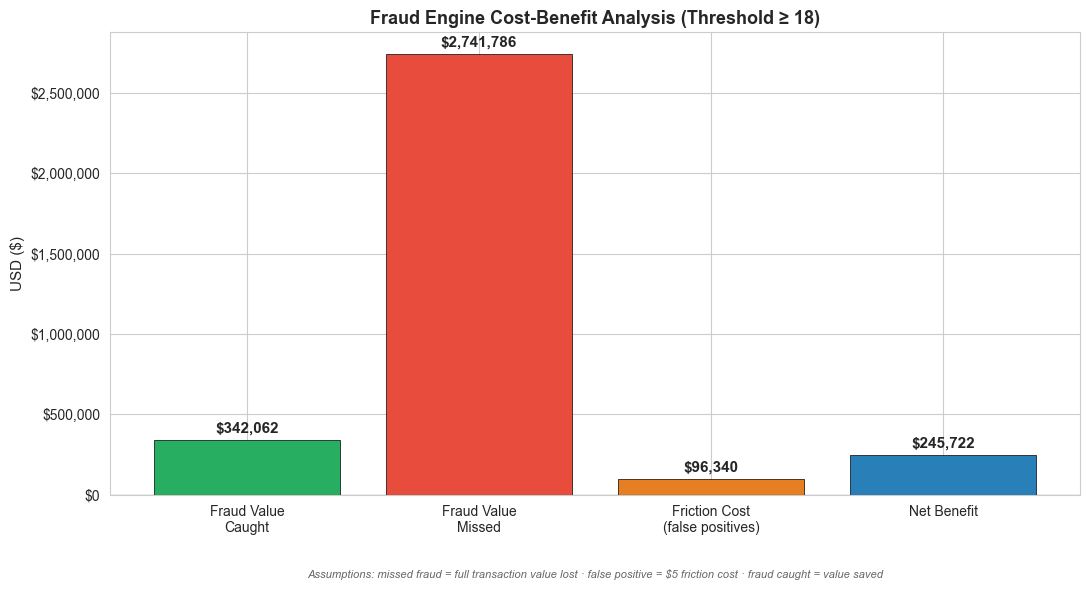

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

categories = ['Fraud Value\nCaught', 'Fraud Value\nMissed', 'Friction Cost\n(false positives)', 'Net Benefit']
values = [cb['fraud_caught'], cb['fraud_missed'], cb['friction_cost'], cb['net_benefit']]

# Green for gains, red for losses/costs, blue for the net
colors = ['#27ae60', '#e74c3c', '#e67e22', '#2980b9']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.5)

# Dollar labels on each bar
for bar, val in zip(bars, values):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    offset = max(values) * 0.01
    ax.text(bar.get_x() + bar.get_width()/2, 
            height + (offset if height >= 0 else -offset),
            f'${val:,.0f}', ha='center', va=va, 
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('USD ($)', fontsize=11)
ax.set_title('Fraud Engine Cost-Benefit Analysis (Threshold ≥ 18)',
             fontsize=13, fontweight='bold')

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x):,}'))

# Footnote stating assumptions
ax.text(0.5, -0.18, 
        'Assumptions: missed fraud = full transaction value lost · '
        'false positive = $5 friction cost · fraud caught = value saved',
        transform=ax.transAxes, ha='center', fontsize=8, 
        style='italic', color='#666')

plt.tight_layout()
plt.savefig('visuals/phase5_cost_benefit.png', bbox_inches='tight')
plt.show()

In [3]:
query = """
with thresholds as (
select generate_series(0,60,2) as threshold
),
metrics as (
	select t.threshold,
	count(*) filter (where s.risk_score >= threshold and s.is_fraud) 	as tp,
	count(*) filter (where s.risk_score >= threshold and not s.is_fraud) 	as fp,
	count(*) filter (where is_fraud)										as tot_fraud
from thresholds t
	cross join fraud_dw.v_scored_transactions s
group by t.threshold,
	(select count(*) filter (where is_fraud) from fraud_dw.v_scored_transactions)		
)
select 
	threshold,
	tp,
	fp,
	round(100.0 * tp::numeric / nullif(tp + fp,0),2) as precesion_pct,
	round(100.0 * tp::numeric / nullif(tot_fraud,0),2) as recall_pct,
	-- F1 score
	round(2.0 * (tp::numeric/nullif(tp+fp,0)) * (tp::numeric / NULLIF(tot_fraud, 0))
		/NULLIF((tp::numeric / NULLIF(tp + fp, 0)) + (tp::numeric / NULLIF(tot_fraud, 0)), 0) * 100, 2) as f1_score
from metrics
order by threshold;
"""

df = pd.read_sql(query,engine)
df.head()

,threshold,tp,fp,precesion_pct,recall_pct,f1_score
0,0,20663,569877,3.50,100.00,6.76
1,2,6327,39299,13.87,30.62,19.09
2,4,6327,39299,13.87,30.62,19.09
3,6,6327,39299,13.87,30.62,19.09
4,8,6327,39299,13.87,30.62,19.09


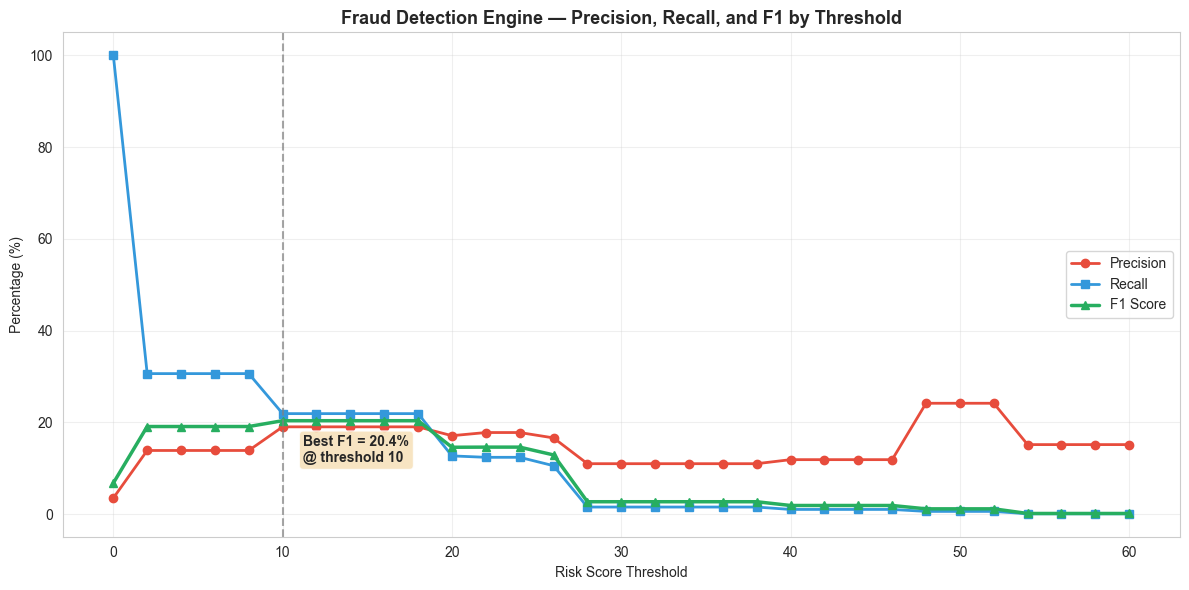

In [4]:
# Threshold sweep results → df
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['threshold'], df['precesion_pct'], 
         color='#e74c3c', marker='o', linewidth=2, label='Precision')
ax1.plot(df['threshold'], df['recall_pct'], 
         color='#3498db', marker='s', linewidth=2, label='Recall')
ax1.plot(df['threshold'], df['f1_score'], 
         color='#27ae60', marker='^', linewidth=2.5, label='F1 Score')

# Mark the best F1 threshold
best = df.loc[df['f1_score'].idxmax()]
ax1.axvline(best['threshold'], color='gray', linestyle='--', alpha=0.7)
ax1.annotate(f"Best F1 = {best['f1_score']:.1f}%\n@ threshold {int(best['threshold'])}",
             (best['threshold'], best['f1_score']),
             textcoords="offset points", xytext=(15, -30),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

ax1.set_xlabel('Risk Score Threshold')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Fraud Detection Engine — Precision, Recall, and F1 by Threshold',
              fontsize=13, fontweight='bold')
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visuals/phase5_pr_curve.png', bbox_inches='tight')
plt.show()